In [1]:
# Cityline EDA + LLM Workflow (Notebook Style)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:

csv_path = "/content/SYRCityline_Requests_2021_Present.csv" # EXAMPLE: /content/cityline_data.csv

df = pd.read_csv(csv_path)
df.head()

,X,Y,Id,Summary,Rating,Address,Description,Agency_Name,Request_type,Lat,...,Created_at_local,Acknowledged_at_local,Closed_at_local,Minutes_to_Acknowledge,Minutes_to_Close,Assignee_name,Category,Sla_in_hours,Report_Source,ObjectId
0,-8.472894e+06,5.319007e+06,18198655,Sewer Back-ups (INTERNAL),1,"435 Ellis St Syracuse, New York, 13210",Dina 450-3461,Water & Sewage,35820.0,43.0462,...,01/14/2025 - 11:19AM,NaN,NaN,NaN,NaN,Assistant Superintendent of Sewers,Sewer Back-ups (INTERNAL),24.0,Request Form,1
1,-8.479295e+06,5.320378e+06,18214945,Other Sewer-related Concerns,1,"609 N Geddes St Syracuse, New York, 13204",Jet Flush- Jerry 439-6961,Water & Sewage,33840.0,43.0552,...,01/16/2025 - 03:37PM,NaN,NaN,NaN,NaN,Assistant Superintendent of Sewers,Other Sewer-related Concerns,24.0,Request Form,2
2,-8.476745e+06,5.313388e+06,18214845,Report Improperly Set Out Trash or Recycling (...,1,"3138 Midland Ave Syracuse NY 13205, United States",NaN,"Garbage, Recycling & Graffiti",34425.0,43.0093,...,01/16/2025 - 03:26PM,NaN,NaN,NaN,NaN,Public Works Inspector- SP,Report Improperly Set Out Trash or Recycling (...,72.0,iPhone,3
3,-8.477781e+06,5.324004e+06,18214835,Traffic & Parking Signs,1,"406 Willumae Dr Syracuse NY 13208, United States",Damaged sign down,Streets & Transportation,34423.0,43.0790,...,01/16/2025 - 03:25PM,NaN,NaN,NaN,NaN,Superintendent of Transportation,Traffic & Parking Signs,120.0,iPhone,4
4,-8.475632e+06,5.320393e+06,18214821,Report an illegally parked vehicle,1,"300-300 Green St Syracuse, NY, 13203, USA",Cars parked illegally and not following odd ev...,Parking & Vehicles,33844.0,43.0553,...,01/16/2025 - 03:24PM,NaN,NaN,NaN,NaN,Syracuse Police Ordinance,Report an illegally parked vehicle,72.0,Portal,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116143 entries, 0 to 116142
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   X                       115919 non-null  float64
 1   Y                       115919 non-null  float64
 2   Id                      116143 non-null  object 
 3   Summary                 116125 non-null  object 
 4   Rating                  116067 non-null  object 
 5   Address                 115933 non-null  object 
 6   Description             100952 non-null  object 
 7   Agency_Name             116031 non-null  object 
 8   Request_type            116028 non-null  float64
 9   Lat                     115922 non-null  float64
 10  Lng                     115919 non-null  float64
 11  Created_at_local        116029 non-null  object 
 12  Acknowledged_at_local   22562 non-null   object 
 13  Closed_at_local         108777 non-null  object 
 14  Minutes_to_Acknowled

In [6]:
# Rename for convenience (optional)
df = df.rename(columns={
    "Created_at_local": "created",
    "Closed_at_local": "closed",
    "Minutes_to_Close": "minutes_to_close",
    "Minutes_to_Acknowledge": "minutes_to_ack",
    "Agency_Name": "agency",
    "Request_type": "request_type",
    "Category": "category",
    "Sla_in_hours": "sla_hours"
})

# Parse dates
df["created"] = pd.to_datetime(df["created"], errors="coerce")
df["closed"] = pd.to_datetime(df["closed"], errors="coerce")

# Resolution in days (from minutes and from timestamps)
df["resolution_days_mins"] = df["minutes_to_close"] / 60 / 24
df["resolution_days_dates"] = (df["closed"] - df["created"]).dt.days

df.describe(include="all")


/tmp/ipython-input-400/1634914786.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["closed"] = pd.to_datetime(df["closed"], errors="coerce")


,X,Y,Id,Summary,Rating,Address,Description,agency,request_type,Lat,...,closed,minutes_to_ack,minutes_to_close,Assignee_name,category,sla_hours,Report_Source,ObjectId,resolution_days_mins,resolution_days_dates
count,1.159190e+05,1.159190e+05,116143,116125,116067,115933,100952,116031,116028.000000,115922.000000,...,108777,22556.000000,1.087760e+05,87643,116053,114801.000000,116042,116143.000000,108776.000000,108776.000000
unique,NaN,NaN,114586,266,52,51768,70526,19,NaN,NaN,...,NaN,NaN,NaN,133,115,NaN,32,NaN,NaN,NaN
top,NaN,NaN,18308406,Large or Bulk Items- Setout notification only,2,"1000 Bellevue Ave Syracuse, NY 13204, USA",couch,"Garbage, Recycling & Graffiti",NaN,NaN,...,NaN,NaN,NaN,Sanitation_Crew_Group,Large or Bulk Items- Setout notification only,NaN,Request Form,NaN,NaN,NaN
freq,NaN,NaN,2,15982,95877,78,1734,65427,NaN,NaN,...,NaN,NaN,NaN,17274,24028,NaN,84373,NaN,NaN,NaN
mean,-8.476316e+06,5.318711e+06,NaN,NaN,NaN,NaN,NaN,NaN,35676.566820,43.041172,...,2023-03-27 15:29:14.927052288,2866.281566,7.756283e+03,NaN,NaN,79.461607,NaN,58072.000000,5.386308,5.009570
min,-8.482913e+06,5.309628e+06,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-76.164600,...,2021-06-22 08:59:00,0.000000,0.000000e+00,NaN,NaN,0.000000,NaN,1.000000,0.000000,0.000000
25%,-8.478170e+06,5.316554e+06,NaN,NaN,NaN,NaN,NaN,NaN,33854.000000,43.030100,...,2022-05-24 09:26:00,10.000000,1.000000e+00,NaN,NaN,48.000000,NaN,29036.500000,0.000694,0.000000
50%,-8.476501e+06,5.318991e+06,NaN,NaN,NaN,NaN,NaN,NaN,33870.000000,43.046100,...,2023-04-18 05:55:00,626.000000,1.327000e+03,NaN,NaN,48.000000,NaN,58072.000000,0.921528,0.000000
75%,-8.474118e+06,5.321505e+06,NaN,NaN,NaN,NaN,NaN,NaN,35820.000000,43.062600,...,2023-12-21 14:32:00,1548.250000,5.273000e+03,NaN,NaN,72.000000,NaN,87107.500000,3.661806,3.000000
max,-8.468897e+06,5.324812e+06,NaN,NaN,NaN,NaN,NaN,NaN,56237.000000,43.084300,...,2025-02-27 14:28:00,462087.000000,1.408207e+06,NaN,NaN,2605.000000,NaN,116143.000000,977.921528,977.000000


In [7]:
# Summary by category
cat_summary = (
    df.groupby("category")
      .agg(
          n_requests=("category", "size"),
          median_res_days=("resolution_days_mins", "median"),
          mean_res_days=("resolution_days_mins", "mean"),
          median_sla_hours=("sla_hours", "median")
      )
      .reset_index()
)
cat_summary.head()


,category,n_requests,median_res_days,mean_res_days,median_sla_hours
0,0,16,NaN,NaN,1.0
1,1.0,1,NaN,NaN,NaN
2,2.0,1,NaN,NaN,NaN
3,2597,1,NaN,NaN,NaN
4,2600,2,NaN,NaN,NaN


In [8]:
# Summary by agency
agency_summary = (
    df.groupby("agency")
      .agg(
          n_requests=("agency", "size"),
          median_res_days=("resolution_days_mins", "median"),
          median_sla_hours=("sla_hours", "median")
      )
      .reset_index()
)
agency_summary.head()


,agency,n_requests,median_res_days,median_sla_hours
0,0,6,0.000000,2604.0
1,1,2,64.225694,2597.0
2,Animals,1093,0.909722,24.0
3,Feedback to the City,631,2.961111,24.0
4,"Garbage, Recycling & Graffiti",65427,0.826389,48.0


In [9]:
# SLA vs actual (where both available)
sla_df = df.dropna(subset=["sla_hours", "minutes_to_close"]).copy()
sla_df["sla_days"] = sla_df["sla_hours"] / 24
sla_df["over_sla_days"] = sla_df["resolution_days_mins"] - sla_df["sla_days"]

sla_df[["category", "agency", "resolution_days_mins", "sla_days", "over_sla_days"]].head()


,category,agency,resolution_days_mins,sla_days,over_sla_days
14,Other Sewer-related Concerns,Water & Sewage,0.023611,1.0,-0.976389
16,Report Litter on Private Land,"Garbage, Recycling & Graffiti",0.001389,2.0,-1.998611
29,Report a Skipped Weekly Trash Pick Up (Internal),Sanitation,0.015972,1.0,-0.984028
45,Home & Building Maintenance,Housing & Property Maintenance,0.002778,2.0,-1.997222
48,Report a Skipped Weekly Trash Pick Up,"Garbage, Recycling & Graffiti",0.010417,2.0,-1.989583


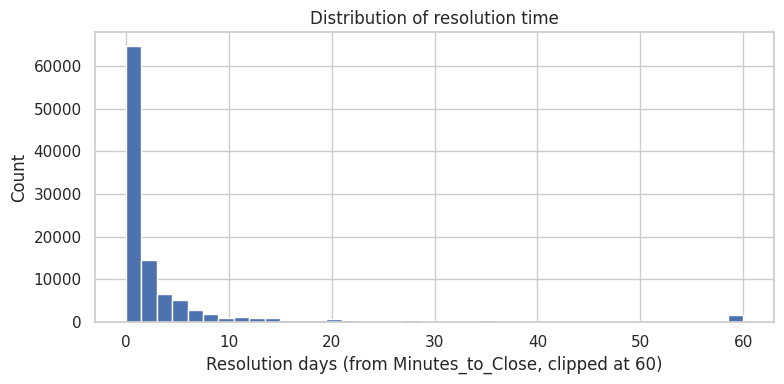

In [10]:
# Distribution of resolution time (days)
plt.figure(figsize=(8, 4))
df["resolution_days_mins"].dropna().clip(lower=0, upper=60).hist(bins=40)
plt.xlabel("Resolution days (from Minutes_to_Close, clipped at 60)")
plt.ylabel("Count")
plt.title("Distribution of resolution time")
plt.tight_layout()
plt.show()


/tmp/ipython-input-400/1134194778.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


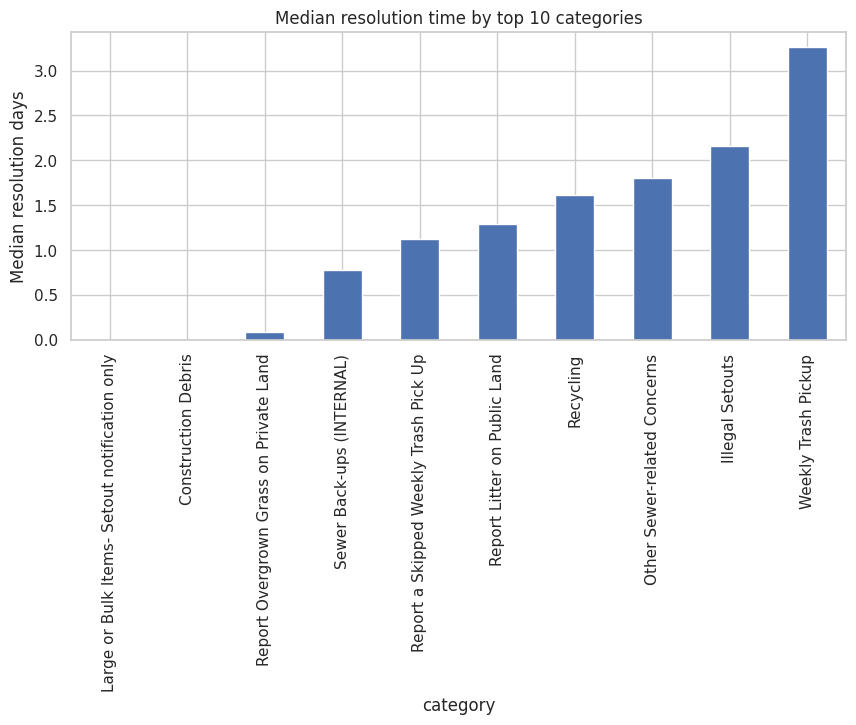

In [11]:
# Top 10 categories by volume and their median resolution days
top_cats = df["category"].value_counts().head(10).index

plt.figure(figsize=(10, 4))
(
    df[df["category"].isin(top_cats)]
    .groupby("category")["resolution_days_mins"]
    .median()
    .sort_values()
    .plot(kind="bar")
)
plt.ylabel("Median resolution days")
plt.title("Median resolution time by top 10 categories")
plt.tight_layout()
plt.show()


/tmp/ipython-input-400/1892652158.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df_time.resample("M")["Id"].size()


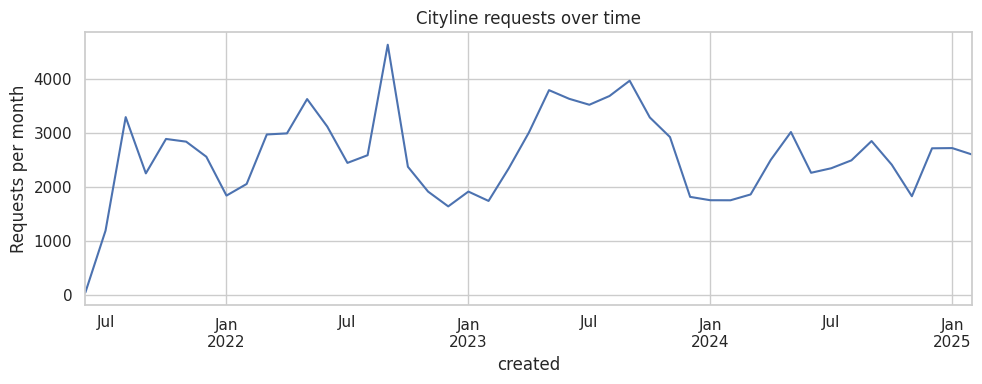

In [12]:
# Requests over time (monthly)
df_time = df.set_index("created").sort_index()
monthly_counts = df_time.resample("M")["Id"].size()

plt.figure(figsize=(10, 4))
monthly_counts.plot()
plt.ylabel("Requests per month")
plt.title("Cityline requests over time")
plt.tight_layout()
plt.show()


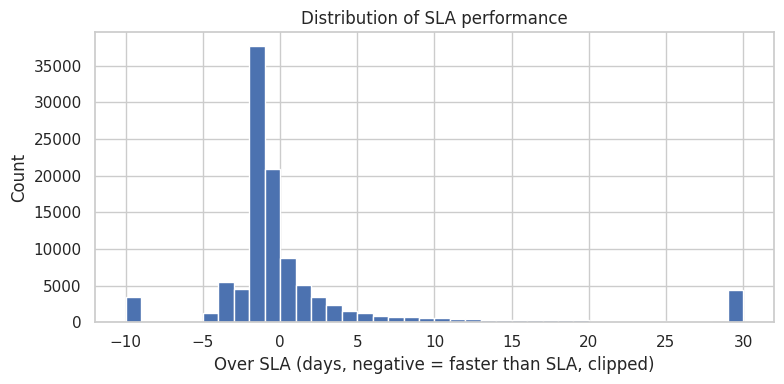

In [13]:
# Over-SLA distribution
plt.figure(figsize=(8, 4))
sla_df["over_sla_days"].dropna().clip(-10, 30).hist(bins=40)
plt.xlabel("Over SLA (days, negative = faster than SLA, clipped)")
plt.ylabel("Count")
plt.title("Distribution of SLA performance")
plt.tight_layout()
plt.show()


In [14]:
# Slowest categories (min volume filter)
min_vol = 50
slow_cats = (
    cat_summary[cat_summary["n_requests"] >= min_vol]
    .sort_values("median_res_days", ascending=False)
    .head(10)
)
slow_cats


,category,n_requests,median_res_days,mean_res_days,median_sla_hours
92,Second Cart Request,471,26.408681,30.559655,NaN
87,SPD Support (Internal),102,25.246875,61.031531,24.0
53,Pavement Markings,197,21.861458,37.898200,288.0
106,Tree Care and Removal,1723,13.818750,21.722302,600.0
111,Water-related Concerns,515,13.665972,50.334261,24.0
48,Overgrown Grass in Public Spaces,235,8.904167,19.272020,72.0
96,Street Lights,1087,8.846181,32.830425,360.0
44,"Other Parks, Trees & Public Utilities Concern",306,6.966667,38.275644,1344.0
51,Parking Meter,78,6.891319,14.194247,120.0
81,Report external dirt/debris blocking a Catch B...,181,6.315278,9.466587,72.0


In [15]:
# Agencies with high volume and long resolution
vol_thresh = agency_summary["n_requests"].quantile(0.75)
slow_agencies = (
    agency_summary[agency_summary["n_requests"] >= vol_thresh]
    .sort_values("median_res_days", ascending=False)
    .head(10)
)
slow_agencies


,agency,n_requests,median_res_days,median_sla_hours
16,"Streets, Sidewalks & Transportation",8576,4.703819,120.0
14,Sanitation Carts,4605,2.897222,48.0
17,Water & Sewage,20409,0.849306,24.0
4,"Garbage, Recycling & Graffiti",65427,0.826389,48.0
7,Housing & Property Maintenance,9521,0.600000,48.0


In [16]:
# Over-SLA by category (median)
over_sla_cat = (
    sla_df.groupby("category")["over_sla_days"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
over_sla_cat.head(10)


,category,over_sla_days
0,SPD Support (Internal),24.246875
1,Carts-Topographically Challenged,17.120833
2,Water-related Concerns,12.665972
3,Pavement Markings,9.861458
4,Overgrown Grass in Public Spaces,5.904167
5,Playground Equipment,4.963194
6,Report internal clogging of a Catch Basin/ Sto...,4.887500
7,Report external dirt/debris blocking a Catch B...,3.093750
8,Cart Stolen,3.032639
9,Report Overgrowth on Public land,2.852083


In [17]:
def build_llm_context(slow_cats, slow_agencies, over_sla_cat):
    lines = []

    lines.append("Slowest categories by median resolution days (min volume):")
    for _, r in slow_cats.iterrows():
        lines.append(
            f"- {r['category']}: median={r['median_res_days']:.1f} days, "
            f"n={int(r['n_requests'])}"
        )

    lines.append("\nHigh-volume agencies with long median resolution:")
    for _, r in slow_agencies.iterrows():
        lines.append(
            f"- {r['agency']}: median={r['median_res_days']:.1f} days, "
            f"n={int(r['n_requests'])}"
        )

    lines.append("\nMedian over-SLA days by category (top 10):")
    for _, r in over_sla_cat.head(10).iterrows():
        lines.append(
            f"- {r['category']}: median over SLA = {r['over_sla_days']:.1f} days"
        )

    return "\n".join(lines)

llm_context = build_llm_context(slow_cats, slow_agencies, over_sla_cat)
print(llm_context)


Slowest categories by median resolution days (min volume):
- Second Cart Request: median=26.4 days, n=471
- SPD Support (Internal): median=25.2 days, n=102
- Pavement Markings: median=21.9 days, n=197
- Tree Care and Removal: median=13.8 days, n=1723
- Water-related Concerns: median=13.7 days, n=515
- Overgrown Grass in Public Spaces: median=8.9 days, n=235
- Street Lights: median=8.8 days, n=1087
- Other Parks, Trees & Public Utilities Concern: median=7.0 days, n=306
- Parking Meter: median=6.9 days, n=78
- Report external dirt/debris blocking a Catch Basin/Storm Drain: median=6.3 days, n=181

High-volume agencies with long median resolution:
- Streets, Sidewalks & Transportation: median=4.7 days, n=8576
- Sanitation Carts: median=2.9 days, n=4605
- Water & Sewage: median=0.8 days, n=20409
- Garbage, Recycling & Graffiti: median=0.8 days, n=65427
- Housing & Property Maintenance: median=0.6 days, n=9521

Median over-SLA days by category (top 10):
- SPD Support (Internal): median over 

In [18]:
# Check rating vs resolution
rating_res = (
    df.dropna(subset=["Rating", "resolution_days_mins"])
      .groupby("Rating")["resolution_days_mins"]
      .median()
      .reset_index()
      .sort_values("resolution_days_mins", ascending=False)
)
rating_res


,Rating,resolution_days_mins
0,-76.1216,64.225694
2,-76.168,62.993750
8,6,20.725000
7,5,9.906944
9,7,6.655556
6,4,5.117361
5,3,2.947222
4,2,0.791667
1,-76.1224,0.000000
3,-76.1808,0.000000


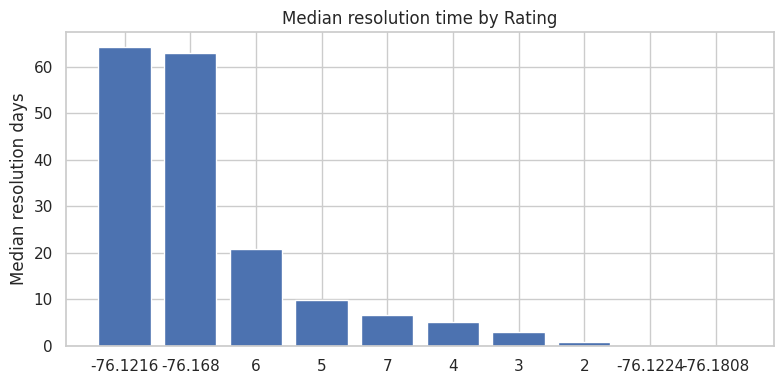

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(rating_res["Rating"], rating_res["resolution_days_mins"])
plt.ylabel("Median resolution days")
plt.title("Median resolution time by Rating")
plt.tight_layout()
plt.show()


In [20]:
neutral_prompt = (
    "Given these statistics on SLA performance by category and agency, "
    "identify data-driven explanations for differences in resolution times."
)

loaded_prompt = (
    "Given these statistics on SLA performance, explain why some agencies "
    "are failing or neglecting their responsibilities."
)

print("Neutral prompt:\n", neutral_prompt)
print("\nLoaded prompt:\n", loaded_prompt)


Neutral prompt:
 Given these statistics on SLA performance by category and agency, identify data-driven explanations for differences in resolution times.

Loaded prompt:
 Given these statistics on SLA performance, explain why some agencies are failing or neglecting their responsibilities.
